In [22]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import random

# Equivalente a: from yahoo_finance import Share; msoft = Share('MSFT')
msoft = yf.Ticker("MSFT")
data = msoft.history(period="1d")

print("Open:", data["Open"].iloc[0])
print("Price:", data["Close"].iloc[0])
print("Datetime:", data.index[0])

Open: 405.8399963378906
Price: 404.8800048828125
Datetime: 2026-03-11 00:00:00-04:00


In [23]:
def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
        print("Loaded from cache:", cache_filename)
    except IOError:
        # Reemplaza: share = Share(share_symbol); share.get_historical()
        df = yf.download(share_symbol, start=start_date, end=end_date, progress=False)
        stock_prices = df["Open"].values.astype(float)
        np.save(cache_filename, stock_prices)
        print("Downloaded and saved to:", cache_filename)
    return stock_prices

In [24]:
def plot_prices(prices):
    plt.figure(figsize=(12, 5))
    plt.title('Opening stock prices')
    plt.xlabel('day')
    plt.ylabel('price ($)')
    plt.plot(prices)
    plt.tight_layout()
    plt.savefig('prices.png')
    plt.show()
    print("Gráfica guardada en prices.png")

In [25]:
class DecisionPolicy:
    def select_action(self, current_state, step):
        pass
    def update_q(self, state, action, reward, next_state):
        pass

In [26]:
class RandomDecisionPolicy(DecisionPolicy):
    def __init__(self, actions):
        self.actions = actions
    def select_action(self, current_state, step):
        action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action

In [27]:
def run_simulation(policy, initial_budget, initial_num_stocks, prices, hist, debug=False):
    budget = initial_budget
    num_stocks = initial_num_stocks
    share_value = 0
    transitions = list()

    for i in range(len(prices) - hist - 1):
        if i % 100 == 0:
            print('progress {:.2f}%'.format(float(100*i) / (len(prices) - hist - 1)))

        current_state = np.asmatrix(np.hstack((prices[i:i+hist], budget, num_stocks)))
        current_portfolio = budget + num_stocks * share_value
        action = policy.select_action(current_state, i)
        share_value = float(prices[i + hist + 1])

        if action == 'Buy' and budget >= share_value:
            budget -= share_value
            num_stocks += 1
        elif action == 'Sell' and num_stocks > 0:
            budget += share_value
            num_stocks -= 1
        else:
            action = 'Hold'

        new_portfolio = budget + num_stocks * share_value
        reward = new_portfolio - current_portfolio
        next_state = np.asmatrix(np.hstack((prices[i+1:i+hist+1], budget, num_stocks)))
        policy.update_q(current_state, action, reward, next_state)
        transitions.append((current_state, action, reward, next_state))

    return budget + num_stocks * share_value

In [28]:
def run_simulations(policy, budget, num_stocks, prices, hist):
    num_tries = 100
    final_portfolios = list()
    for i in range(num_tries):
        final_portfolio = run_simulation(policy, budget, num_stocks, prices, hist)
        final_portfolios.append(final_portfolio)
    avg, std = np.mean(final_portfolios), np.std(final_portfolios)
    return avg, std

In [29]:
import tensorflow as tf
from tensorflow import keras

class QLearningDecisionPolicy(DecisionPolicy):
    def __init__(self, actions, input_dim):
        self.epsilon = 0.9
        self.gamma = 0.001
        self.actions = actions
        output_dim = len(actions)
        h1_dim = 200

        # Reemplaza tf.placeholder / tf.Session (TF1) con Keras (TF2)
        self.model = keras.Sequential([
            keras.layers.Dense(h1_dim, activation='relu', input_shape=(input_dim,)),
            keras.layers.Dense(output_dim, activation='relu')
        ])
        self.model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01),
            loss='mse'
        )

    def select_action(self, current_state, step):
        threshold = min(self.epsilon, step / 1000.)
        if random.random() < threshold:
            # Exploit: mejor acción según Q
            action_q_vals = self.model.predict(current_state, verbose=0)
            action_q_vals = np.squeeze(np.asarray(action_q_vals))
            action_idx = np.argmax(action_q_vals)
            action = self.actions[action_idx]
        else:
            # Explore: acción aleatoria
            action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action

    def update_q(self, state, action, reward, next_state):
        action_idx = self.actions.index(action)
        action_q_vals = self.model.predict(state, verbose=0)
        action_q_vals = np.squeeze(np.asarray(action_q_vals))
        next_q_vals = self.model.predict(next_state, verbose=0)
        next_q_vals = np.squeeze(np.asarray(next_q_vals))
        # Ecuación de Bellman
        action_q_vals[action_idx] = reward + self.gamma * np.max(next_q_vals)
        self.model.fit(state, action_q_vals.reshape(1, -1), epochs=1, verbose=0)

Loaded from cache: historical_stock_prices.npy


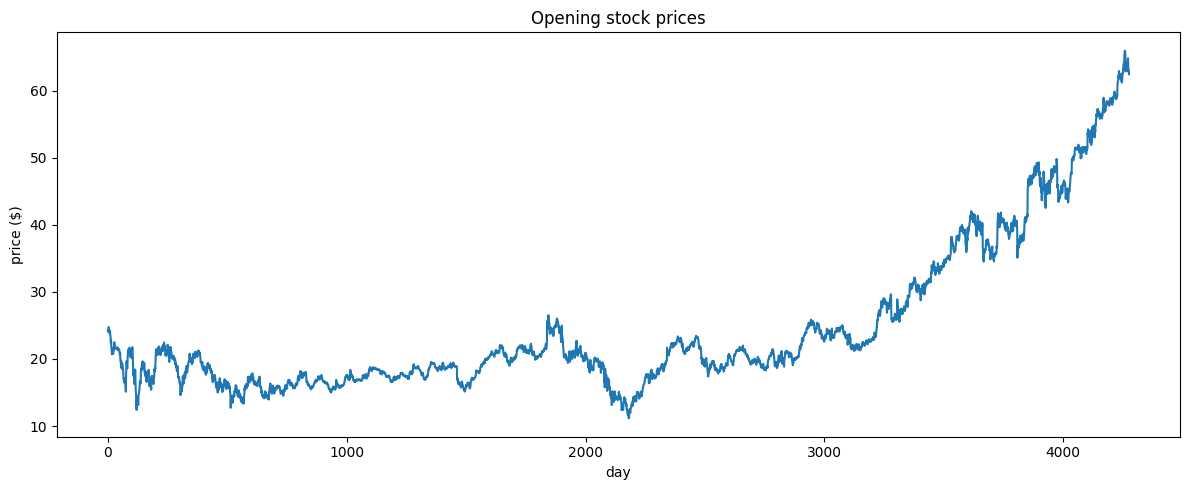

Gráfica guardada en prices.png
progress 0.00%


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

In [30]:
# === MAIN ===
prices = get_prices('MSFT', '2000-07-01', '2017-07-01', 'historical_stock_prices.npy')
plot_prices(prices)

actions = ['Buy', 'Sell', 'Hold']
hist = 200
policy = RandomDecisionPolicy(actions)
budget = 1000.0
num_stocks = 0

avg, std = run_simulations(policy, budget, num_stocks, prices, hist)
print(avg, std)

In [31]:
import os
print(os.getcwd())

c:\Users\elyix\Downloads
